<a href="https://colab.research.google.com/github/MuhammadFarhan96/CodeAlpha_credit_scoring/blob/main/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Credit Scoring Model

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = pd.read_csv("/content/german_credit_data.csv")

# Remove unnecessary column
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

# Fill missing values
data.fillna("Unknown", inplace=True)

# Convert categorical columns
encoder = LabelEncoder()

for column in data.columns:

    if data[column].dtype == object:

        data[column] = encoder.fit_transform(data[column])

# Features and target
X = data.drop("Risk", axis=1)

y = data["Risk"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))

Accuracy: 0.755
              precision    recall  f1-score   support

           0       0.62      0.42      0.51        59
           1       0.79      0.89      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.66      0.67       200
weighted avg       0.74      0.76      0.74       200



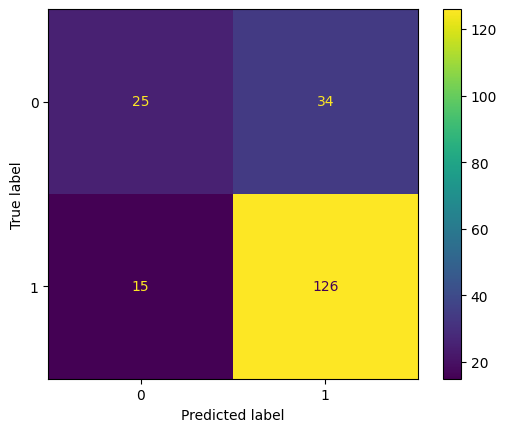

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()